## RAG Pipelines- Data Ingestion to Vector DB Pipeline

In [1]:
import os
from langchain_community.document_loaders import PyPDFLoader, PyMuPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from pathlib import Path

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9376\3933654057.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader, PyMuPDFLoader


In [8]:
### Read all the pdf's inside the directory
def process_all_pdfs(pdf_directory):
    """Process all PDF files in a directory"""
    all_documents = []
    pdf_dir = Path(pdf_directory)
    
    # Find all PDF files recursively
    pdf_files = list(pdf_dir.glob("**/*.pdf"))
    
    print(f"Found {len(pdf_files)} PDF files to process")
    
    for pdf_file in pdf_files:
        print(f"\nProcessing: {pdf_file.name}")
        try:
            loader = PyPDFLoader(str(pdf_file))
            documents = loader.load()
            
            # Add source information to metadata
            for doc in documents:
                doc.metadata['source_file'] = pdf_file.name
                doc.metadata['file_type'] = 'pdf'
            
            all_documents.extend(documents)
            print(f"  ✓ Loaded {len(documents)} pages")
            
        except Exception as e:
            print(f"  ✗ Error: {e}")
    
    print(f"\nTotal documents loaded: {len(all_documents)}")
    return all_documents

# Process all PDFs in the data directory
all_pdf_documents = process_all_pdfs("../data")

Found 4 PDF files to process

Processing: attention.pdf


Multiple definitions in dictionary at byte 0x2251 for key /ToUnicode
Multiple definitions in dictionary at byte 0x22f8 for key /ToUnicode
Multiple definitions in dictionary at byte 0x239f for key /ToUnicode
Multiple definitions in dictionary at byte 0x2448 for key /ToUnicode
Multiple definitions in dictionary at byte 0x24f1 for key /ToUnicode
Multiple definitions in dictionary at byte 0x2598 for key /ToUnicode
Multiple definitions in dictionary at byte 0x263f for key /ToUnicode
Multiple definitions in dictionary at byte 0x26e5 for key /ToUnicode
Multiple definitions in dictionary at byte 0x278c for key /ToUnicode
Multiple definitions in dictionary at byte 0x2831 for key /ToUnicode
Multiple definitions in dictionary at byte 0x28da for key /ToUnicode
Multiple definitions in dictionary at byte 0x2981 for key /ToUnicode


  ✓ Loaded 15 pages

Processing: embeddings.pdf
  ✓ Loaded 27 pages

Processing: objectdetection.pdf
  ✓ Loaded 88 pages

Processing: proposals.pdf
  ✓ Loaded 3 pages

Total documents loaded: 133


In [4]:
all_pdf_documents

[Document(metadata={'producer': 'pdfTeX-1.40.25', 'creator': 'LaTeX with hyperref', 'creationdate': '2024-04-10T21:11:43+00:00', 'author': '', 'keywords': '', 'moddate': '2024-04-10T21:11:43+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023) kpathsea version 6.3.5', 'subject': '', 'title': '', 'trapped': '/False', 'source': '..\\data\\pdf\\attention.pdf', 'total_pages': 15, 'page': 0, 'page_label': '1', 'source_file': 'attention.pdf', 'file_type': 'pdf'}, page_content='Provided proper attribution is provided, Google hereby grants permission to\nreproduce the tables and figures in this paper solely for use in journalistic or\nscholarly works.\nAttention Is All You Need\nAshish Vaswani∗\nGoogle Brain\navaswani@google.com\nNoam Shazeer∗\nGoogle Brain\nnoam@google.com\nNiki Parmar∗\nGoogle Research\nnikip@google.com\nJakob Uszkoreit∗\nGoogle Research\nusz@google.com\nLlion Jones∗\nGoogle Research\nllion@google.com\nAidan N. Gomez∗†\nUniversity of To

## Chunking

Text Splitting get into chunks

In [2]:
### Text splitting get into chunks

def split_documents(documents,chunk_size=1000,chunk_overlap=200):
    """Split documents into smaller chunks for better RAG performance"""
    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        length_function=len,
        separators=["\n\n", "\n", " ", ""]
    )
    split_docs = text_splitter.split_documents(documents)
    print(f"Split {len(documents)} documents into {len(split_docs)} chunks")
    
    # Show example of a chunk
    if split_docs:
        print(f"\nExample chunk:")
        print(f"Content: {split_docs[0].page_content[:200]}...")
        print(f"Metadata: {split_docs[0].metadata}")
    
    return split_docs

In [10]:
chunks=split_documents(all_pdf_documents)
chunks

Split 133 documents into 259 chunks

Example chunk:
Content: Provided proper attribution is provided, Google hereby grants permission to
reproduce the tables and figures in this paper solely for use in journalistic or
scholarly works.
Attention Is All You Need
...
Metadata: {'producer': 'pdfTeX-1.40.25', 'creator': 'LaTeX with hyperref', 'creationdate': '2024-04-10T21:11:43+00:00', 'author': '', 'keywords': '', 'moddate': '2024-04-10T21:11:43+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023) kpathsea version 6.3.5', 'subject': '', 'title': '', 'trapped': '/False', 'source': '..\\data\\pdf\\attention.pdf', 'total_pages': 15, 'page': 0, 'page_label': '1', 'source_file': 'attention.pdf', 'file_type': 'pdf'}


[Document(metadata={'producer': 'pdfTeX-1.40.25', 'creator': 'LaTeX with hyperref', 'creationdate': '2024-04-10T21:11:43+00:00', 'author': '', 'keywords': '', 'moddate': '2024-04-10T21:11:43+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023) kpathsea version 6.3.5', 'subject': '', 'title': '', 'trapped': '/False', 'source': '..\\data\\pdf\\attention.pdf', 'total_pages': 15, 'page': 0, 'page_label': '1', 'source_file': 'attention.pdf', 'file_type': 'pdf'}, page_content='Provided proper attribution is provided, Google hereby grants permission to\nreproduce the tables and figures in this paper solely for use in journalistic or\nscholarly works.\nAttention Is All You Need\nAshish Vaswani∗\nGoogle Brain\navaswani@google.com\nNoam Shazeer∗\nGoogle Brain\nnoam@google.com\nNiki Parmar∗\nGoogle Research\nnikip@google.com\nJakob Uszkoreit∗\nGoogle Research\nusz@google.com\nLlion Jones∗\nGoogle Research\nllion@google.com\nAidan N. Gomez∗†\nUniversity of To

## Embedding And VectorStoreDB

In [3]:
import numpy as np
from sentence_transformers import SentenceTransformer
import chromadb
from chromadb.config import Settings
import uuid
from typing import List, Dict, Any, Tuple
from sklearn.metrics.pairwise import cosine_similarity

c:\Users\Lenovo\Desktop\Agentic AI\RAG_Pract\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
class EmbeddingManager:
    """Handles document embedding generation using SentenceTransformer"""
    
    def __init__(self, model_name: str = "all-MiniLM-L6-v2"):
        """
        Initialize the embedding manager
        
        Args:
            model_name: HuggingFace model name for sentence embeddings
        """
        self.model_name = model_name
        self.model = None
        self._load_model()

    def _load_model(self):
        """Load the SentenceTransformer model"""
        try:
            print(f"Loading embedding model: {self.model_name}")
            self.model = SentenceTransformer(self.model_name)
            print(f"Model loaded successfully. Embedding dimension: {self.model.get_sentence_embedding_dimension()}")
        except Exception as e:
            print(f"Error loading model {self.model_name}: {e}")
            raise

    def generate_embeddings(self, texts: List[str]) -> np.ndarray:
        """
        Generate embeddings for a list of texts
        
        Args:
            texts: List of text strings to embed
            
        Returns:
            numpy array of embeddings with shape (len(texts), embedding_dim)
        """
        if not self.model:
            raise ValueError("Model not loaded")
        
        print(f"Generating embeddings for {len(texts)} texts...")

        embeddings = self.model.encode(texts, show_progress_bar=True)
        
        print(f"Generated embeddings with shape: {embeddings.shape}")
        return embeddings


## initialize the embedding manager

embedding_manager=EmbeddingManager()
embedding_manager

Loading embedding model: all-MiniLM-L6-v2


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3120.85it/s]


Model loaded successfully. Embedding dimension: 384


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9376\3068200678.py:20: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print(f"Model loaded successfully. Embedding dimension: {self.model.get_sentence_embedding_dimension()}")


## VectorStore

In [5]:
class VectorStore:
    """Manages document embeddings in a ChromaDB vector store"""
    
    def __init__(self, collection_name: str = "pdf_documents", persist_directory: str = "../data/vector_store"):
        """
        Initialize the vector store
        
        Args:
            collection_name: Name of the ChromaDB collection
            persist_directory: Directory to persist the vector store
        """
        self.collection_name = collection_name
        self.persist_directory = persist_directory
        self.client = None
        self.collection = None
        self._initialize_store()

    def _initialize_store(self):
        """Initialize ChromaDB client and collection"""
        try:
            # Create persistent ChromaDB client
            os.makedirs(self.persist_directory, exist_ok=True)
            self.client = chromadb.PersistentClient(path=self.persist_directory)
            
            # Get or create collection
            self.collection = self.client.get_or_create_collection(
                name=self.collection_name,
                metadata={"description": "PDF document embeddings for RAG"}
            )
            print(f"Vector store initialized. Collection: {self.collection_name}")
            print(f"Existing documents in collection: {self.collection.count()}")
            
        except Exception as e:
            print(f"Error initializing vector store: {e}")
            raise

    def add_documents(self, documents: List[Any], embeddings: np.ndarray):
        """
        Add documents and their embeddings to the vector store
        
        Args:
            documents: List of LangChain documents
            embeddings: Corresponding embeddings for the documents
        """
        if len(documents) != len(embeddings):
            raise ValueError("Number of documents must match number of embeddings")
        
        print(f"Adding {len(documents)} documents to vector store...")
        
        # Prepare data for ChromaDB
        ids = []
        metadatas = []
        documents_text = []
        embeddings_list = []
        
        for i, (doc, embedding) in enumerate(zip(documents, embeddings)):
            # Generate unique ID
            doc_id = f"doc_{uuid.uuid4().hex[:8]}_{i}"
            ids.append(doc_id)
            
            # Prepare metadata
            metadata = dict(doc.metadata)
            metadata['doc_index'] = i
            metadata['content_length'] = len(doc.page_content)
            metadatas.append(metadata)
            
            # Document content
            documents_text.append(doc.page_content)
            
            # Embedding
            embeddings_list.append(embedding.tolist())
        
        # Add to collection
        try:
            self.collection.add(
                ids=ids,
                embeddings=embeddings_list,
                metadatas=metadatas,
                documents=documents_text
            )
            print(f"Successfully added {len(documents)} documents to vector store")
            print(f"Total documents in collection: {self.collection.count()}")
            
        except Exception as e:
            print(f"Error adding documents to vector store: {e}")
            raise

vectorstore=VectorStore()
vectorstore

Vector store initialized. Collection: pdf_documents
Existing documents in collection: 259


In [ ]:
chunks

In [11]:
### Convert the text to embeddings
texts=[doc.page_content for doc in chunks]

## Generate the Embeddings

embeddings=embedding_manager.generate_embeddings(texts)

##store in the vector database
vectorstore.add_documents(chunks,embeddings)

Generating embeddings for 259 texts...


Batches: 100%|██████████| 9/9 [00:12<00:00,  1.39s/it]


Generated embeddings with shape: (259, 384)
Adding 259 documents to vector store...
Successfully added 259 documents to vector store
Total documents in collection: 518


## RAG Retriever Pipeline

In [12]:
class RAGRetriever:
    """Handles query-based retrieval from the vector store"""
    
    def __init__(self, vector_store: VectorStore, embedding_manager: EmbeddingManager):
        """
        Initialize the retriever
        
        Args:
            vector_store: Vector store containing document embeddings
            embedding_manager: Manager for generating query embeddings
        """
        self.vector_store = vector_store
        self.embedding_manager = embedding_manager

    def retrieve(self, query: str, top_k: int = 5, score_threshold: float = 0.0) -> List[Dict[str, Any]]:
        """
        Retrieve relevant documents for a query
        
        Args:
            query: The search query
            top_k: Number of top results to return
            score_threshold: Minimum similarity score threshold
            
        Returns:
            List of dictionaries containing retrieved documents and metadata
        """
        print(f"Retrieving documents for query: '{query}'")
        print(f"Top K: {top_k}, Score threshold: {score_threshold}")
        
        # Generate query embedding
        query_embedding = self.embedding_manager.generate_embeddings([query])[0]
        
        # Search in vector store
        try:
            results = self.vector_store.collection.query(
                query_embeddings=[query_embedding.tolist()],
                n_results=top_k
            )
            
            # Process results
            retrieved_docs = []
            
            if results['documents'] and results['documents'][0]:
                documents = results['documents'][0]
                metadatas = results['metadatas'][0]
                distances = results['distances'][0]
                ids = results['ids'][0]
                
                for i, (doc_id, document, metadata, distance) in enumerate(zip(ids, documents, metadatas, distances)):
                    # Convert distance to similarity score (ChromaDB uses cosine distance)
                    similarity_score = 1 - distance
                    
                    if similarity_score >= score_threshold:
                        retrieved_docs.append({
                            'id': doc_id,
                            'content': document,
                            'metadata': metadata,
                            'similarity_score': similarity_score,
                            'distance': distance,
                            'rank': i + 1
                        })
                
                print(f"Retrieved {len(retrieved_docs)} documents (after filtering)")
            else:
                print("No documents found")
            
            return retrieved_docs
            
        except Exception as e:
            print(f"Error during retrieval: {e}")
            return []

rag_retriever=RAGRetriever(vectorstore,embedding_manager)

In [13]:
rag_retriever

In [14]:
rag_retriever.retrieve("What is attention is all you need")

Retrieving documents for query: 'What is attention is all you need'
Top K: 5, Score threshold: 0.0
Generating embeddings for 1 texts...


Batches: 100%|██████████| 1/1 [00:00<00:00, 52.02it/s]

Generated embeddings with shape: (1, 384)
Retrieved 2 documents (after filtering)


[{'id': 'doc_bd32dcab_12',
  'content': '3.2 Attention\nAn attention function can be described as mapping a query and a set of key-value pairs to an output,\nwhere the query, keys, values, and output are all vectors. The output is computed as a weighted sum\n3',
  'metadata': {'content_length': 216,
   'total_pages': 15,
   'file_type': 'pdf',
   'creationdate': '2024-04-10T21:11:43+00:00',
   'moddate': '2024-04-10T21:11:43+00:00',
   'source': '..\\data\\pdf\\attention.pdf',
   'page_label': '3',
   'source_file': 'attention.pdf',
   'page': 2,
   'subject': '',
   'doc_index': 12,
   'keywords': '',
   'creator': 'LaTeX with hyperref',
   'producer': 'pdfTeX-1.40.25',
   'trapped': '/False',
   'title': '',
   'author': '',
   'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023) kpathsea version 6.3.5'},
  'similarity_score': 0.13995468616485596,
  'distance': 0.860045313835144,
  'rank': 1},
 {'id': 'doc_0d22c232_12',
  'content': '3.2 Attention\nAn a

In [16]:
rag_retriever.retrieve("What is object detection")

Retrieving documents for query: 'What is object detection'
Top K: 5, Score threshold: 0.0
Generating embeddings for 1 texts...


Batches: 100%|██████████| 1/1 [00:00<00:00, 92.54it/s]

Generated embeddings with shape: (1, 384)
Retrieved 5 documents (after filtering)


[{'id': 'doc_1a45b3c0_166',
  'content': 'What  is object detection\nhttp://cs231n.stanford.edu/slides/winter1516_lecture8.pdf',
  'metadata': {'doc_index': 166,
   'creator': 'Google',
   'content_length': 83,
   'page_label': '3',
   'producer': 'PyPDF',
   'source': '..\\data\\pdf\\objectdetection.pdf',
   'creationdate': '',
   'source_file': 'objectdetection.pdf',
   'total_pages': 88,
   'file_type': 'pdf',
   'page': 2},
  'similarity_score': 0.6884917914867401,
  'distance': 0.3115082085132599,
  'rank': 1},
 {'id': 'doc_4be10d5f_166',
  'content': 'What  is object detection\nhttp://cs231n.stanford.edu/slides/winter1516_lecture8.pdf',
  'metadata': {'creator': 'Google',
   'producer': 'PyPDF',
   'creationdate': '',
   'page_label': '3',
   'source': '..\\data\\pdf\\objectdetection.pdf',
   'doc_index': 166,
   'source_file': 'objectdetection.pdf',
   'total_pages': 88,
   'page': 2,
   'content_length': 83,
   'file_type': 'pdf'},
  'similarity_score': 0.6884917914867401,
  'd

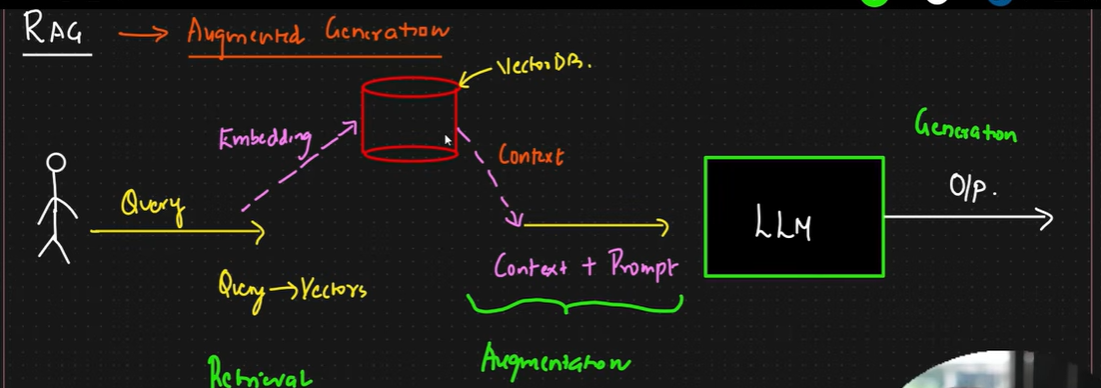

## VectorDB To LLM Output Generation

In [18]:
from langchain.agents import create_agent
from langchain_openai import ChatOpenAI
from langchain.messages import SystemMessage, HumanMessage,AIMessage
import os
from dotenv import load_dotenv


load_dotenv()

llm = ChatOpenAI(
    model="prism-ml/ternary-bonsai-2-27b",
    api_key=os.getenv("OPENROUTER_API_KEY"),
    base_url="https://openrouter.ai/api/v1",
    max_tokens=1000,
)

In [19]:
## 2. Simple RAG function: retrieve context + generate response
def rag_simple(query,retriever,llm,top_k=3):
    ## retriever the context
    results=retriever.retrieve(query,top_k=top_k)
    context="\n\n".join([doc['content'] for doc in results]) if results else ""
    if not context:
        return "No relevant context found to answer the question."
    
    ## generate the answwer using GROQ LLM
    prompt=f"""Use the following context to answer the question concisely.
        Context:
        {context}

        Question: {query}

        Answer:"""
    
    response=llm.invoke([prompt.format(context=context,query=query)])
    return response.content

In [20]:
answer=rag_simple("What is attention mechanism?",rag_retriever,llm)
print(answer)

Retrieving documents for query: 'What is attention mechanism?'
Top K: 3, Score threshold: 0.0
Generating embeddings for 1 texts...


Batches: 100%|██████████| 1/1 [00:00<00:00,  3.37it/s]


Generated embeddings with shape: (1, 384)
Retrieved 3 documents (after filtering)


An attention mechanism maps a query and a set of key–value pairs to an output vector, computed as a weighted sum, allowing it to focus on relevant parts of the input.


## Enhanced RAG Pipeline

In [21]:
# --- Enhanced RAG Pipeline Features ---
def rag_advanced(query, retriever, llm, top_k=5, min_score=0.2, return_context=False):
    """
    RAG pipeline with extra features:
    - Returns answer, sources, confidence score, and optionally full context.
    """
    results = retriever.retrieve(query, top_k=top_k, score_threshold=min_score)
    if not results:
        return {'answer': 'No relevant context found.', 'sources': [], 'confidence': 0.0, 'context': ''}
    
    # Prepare context and sources
    context = "\n\n".join([doc['content'] for doc in results])
    sources = [{
        'source': doc['metadata'].get('source_file', doc['metadata'].get('source', 'unknown')),
        'page': doc['metadata'].get('page', 'unknown'),
        'score': doc['similarity_score'],
        'preview': doc['content'][:300] + '...'
    } for doc in results]
    confidence = max([doc['similarity_score'] for doc in results])
    
    # Generate answer
    prompt = f"""Use the following context to answer the question concisely.\nContext:\n{context}\n\nQuestion: {query}\n\nAnswer:"""
    response = llm.invoke([prompt.format(context=context, query=query)])
    
    output = {
        'answer': response.content,
        'sources': sources,
        'confidence': confidence
    }
    if return_context:
        output['context'] = context
    return output

# Example usage:
result = rag_advanced("Hard Negative Mining Technqiues", rag_retriever, llm, top_k=3, min_score=0.1, return_context=True)
print("Answer:", result['answer'])
print("Sources:", result['sources'])
print("Confidence:", result['confidence'])
print("Context Preview:", result['context'][:300])

Retrieving documents for query: 'Hard Negative Mining Technqiues'
Top K: 3, Score threshold: 0.1
Generating embeddings for 1 texts...


Batches: 100%|██████████| 1/1 [00:00<00:00, 47.19it/s]

Generated embeddings with shape: (1, 384)
Retrieved 2 documents (after filtering)


Answer: 

Hard Negative Mining uses negative examples with higher confidence scores to reduce imbalance between positive and negative examples.
Sources: [{'source': 'objectdetection.pdf', 'page': 7, 'score': 0.18127697706222534, 'preview': 'Hard Negative Mining\nImbalance between positive and negative examples.\nUse negative examples with higher confidence score.\nNon Maximum Suppression\nIf output boxes overlap, only consider the most confident....'}, {'source': 'objectdetection.pdf', 'page': 7, 'score': 0.18127697706222534, 'preview': 'Hard Negative Mining\nImbalance between positive and negative examples.\nUse negative examples with higher confidence score.\nNon Maximum Suppression\nIf output boxes overlap, only consider the most confident....'}]
Confidence: 0.18127697706222534
Context Preview: Hard Negative Mining
Imbalance between positive and negative examples.
Use negative examples with higher confidence score.
Non Maximum Suppression
If output boxes overlap, only consider the m